In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

# Memuat dataset Iris
iris = load_iris()

# Membagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(
    iris.data,
    iris.target,
    random_state=42
)

# Membuat dan melatih model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

# Menghitung akurasi
print("Training set score: {:.3f}".format(logreg.score(X_train, y_train)))
print("Test set score: {:.3f}".format(logreg.score(X_test, y_test)))

# Prediksi
y_pred = logreg.predict(X_test)

print("\nPrediksi:")
print(y_pred[:10])

print("\nLabel sebenarnya:")
print(y_test[:10])

Training set score: 0.964
Test set score: 1.000

Prediksi:
[1 0 2 1 1 0 1 2 1 1]

Label sebenarnya:
[1 0 2 1 1 0 1 2 1 1]


Dataset ini akan digunakan untuk mendemonstrasikan teknik cross-validation dan grid search.

** Cross-Validation Dasar dengan cross_val_score**

In [3]:
from sklearn.model_selection import cross_val_score

logreg = LogisticRegression(max_iter=1000)
scores = cross_val_score(logreg, iris.data, iris.target)
print(f"Skor Cross-validation: {scores}")

Skor Cross-validation: [0.96666667 1.         0.93333333 0.96666667 1.        ]


Cross-validation (CV) adalah metode statistik untuk mengevaluasi kinerja generalisasi yang lebih stabil daripada satu kali split. Secara default, cross_val_score saat ini melakukan 5-fold CV (di versi scikit-learn terbaru).


**Mengatur Jumlah Fold (cv)**

In [4]:
# Melakukan cross-validation dengan 10 fold
scores = cross_val_score(logreg, iris.data, iris.target, cv=10)
print(f"Skor CV (10 fold): {scores}")

Skor CV (10 fold): [1.         0.93333333 1.         1.         0.93333333 0.93333333
 0.93333333 1.         1.         1.        ]


Semakin banyak fold, semakin banyak model yang dilatih, sehingga evaluasi menjadi lebih teliti namun memakan waktu lebih lama.

**Menghitung Rata-rata Skor CV**

In [5]:
print(f"Rata-rata skor CV: {scores.mean():.2f}")

Rata-rata skor CV: 0.97


Cara paling umum untuk merangkum hasil cross-validation adalah dengan menghitung rata-rata dari semua skor fold untuk mendapatkan estimasi performa model yang diharapkan pada data baru

**Masalah KFold Standar pada Data Terurut**

In [6]:
from sklearn.model_selection import KFold
kfold = KFold(n_splits=3)
print(f"Skor CV dengan KFold standar (3 splits):\n{cross_val_score(logreg, iris.data, iris.target, cv=kfold)}")

Skor CV dengan KFold standar (3 splits):
[0. 0. 0.]


Pada dataset Iris, data terurut berdasarkan label kelas. Jika kita menggunakan KFold standar (tanpa acak) dengan 3 split, setiap fold hanya berisi satu kelas, sehingga akurasinya akan menjadi 0%.

**Solusi: KFold dengan Shuffle**

In [7]:
kfold = KFold(n_splits=3, shuffle=True, random_state=0)
print(f"Skor CV dengan KFold acak (3 splits):\n{cross_val_score(logreg, iris.data, iris.target, cv=kfold)}")

Skor CV dengan KFold acak (3 splits):
[0.98 0.96 0.96]


Mengaktifkan shuffle=True akan mengacak data sebelum dipisahkan menjadi fold, yang memecahkan masalah data terurut dan menghasilkan evaluasi yang valid.

**Leave-One-Out Cross-Validation**

In [8]:
from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()
scores = cross_val_score(logreg, iris.data, iris.target, cv=loo)
print(f"Jumlah iterasi CV: {len(scores)}")
print(f"Rata-rata akurasi: {scores.mean():.2f}")

Jumlah iterasi CV: 150
Rata-rata akurasi: 0.97


Leave-one-out memperlakukan setiap sampel tunggal sebagai data tes. Ini sangat berguna untuk dataset yang sangat kecil guna mendapatkan estimasi yang lebih baik.

**Shuffle-Split Cross-Validation**

In [9]:
from sklearn.model_selection import ShuffleSplit
shuffle_split = ShuffleSplit(test_size=.5, train_size=.5, n_splits=10)
scores = cross_val_score(logreg, iris.data, iris.target, cv=shuffle_split)
print(f"Skor CV (ShuffleSplit):\n{scores}")

Skor CV (ShuffleSplit):
[0.94666667 0.96       0.94666667 0.97333333 0.94666667 0.96
 0.97333333 0.94666667 0.96       0.94666667]


Metode ini memungkinkan kontrol independen terhadap jumlah iterasi dan ukuran data training/testing di setiap split

**Cross-Validation dengan Groups (GroupKFold)**

In [11]:
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression

# Membuat data sintetis
X, y = make_blobs(n_samples=12, random_state=0)

# 4 grup, masing-masing berisi 3 sampel
groups = [0, 0, 0,
          1, 1, 1,
          2, 2, 2,
          3, 3, 3]

# Model
logreg = LogisticRegression(max_iter=1000)

# Cross Validation berbasis grup
scores = cross_val_score(
    logreg,
    X,
    y,
    groups=groups,
    cv=GroupKFold(n_splits=3)
)

print("Skor CV dengan grup:")
print(scores)

Skor CV dengan grup:
[0.5        0.66666667 1.        ]


roupKFold digunakan jika data memiliki ketergantungan (misal: beberapa foto dari orang yang sama). Teknik ini memastikan data dari grup yang sama tidak tersebar di training dan test set sekaligus.

**Grid Search Sederhana (Nested Loops)**

In [12]:
from sklearn.svm import SVC
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, random_state=0)

best_score = 0
for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        svm = SVC(gamma=gamma, C=C)
        svm.fit(X_train, y_train)
        score = svm.score(X_test, y_test)
        if score > best_score:
            best_score = score
            best_parameters = {'C': C, 'gamma': gamma}

print(f"Skor terbaik: {best_score:.2f}")
print(f"Parameter terbaik: {best_parameters}")

Skor terbaik: 0.97
Parameter terbaik: {'C': 100, 'gamma': 0.001}


Grid search mencoba semua kombinasi parameter yang diberikan untuk menemukan yang terbaik. Namun, menggunakan data tes untuk tuning parameter seperti ini berisiko overfitting pada data tes tersebut.

**Grid Search dengan Validation Set**

In [13]:
# Membagi data menjadi training+validation dan test
X_trainval, X_test, y_trainval, y_test = train_test_split(iris.data, iris.target, random_state=0)
# Membagi training+validation menjadi training dan validation set yang terpisah
X_train, X_valid, y_train, y_valid = train_test_split(X_trainval, y_trainval, random_state=1)

best_score = 0
for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        svm = SVC(gamma=gamma, C=C).fit(X_train, y_train)
        score = svm.score(X_valid, y_valid)
        if score > best_score:
            best_score = score
            best_parameters = {'C': C, 'gamma': gamma}

# Membangun kembali model dengan parameter terbaik pada data train+val
svm = SVC(**best_parameters).fit(X_trainval, y_trainval)
print(f"Skor tes akhir: {svm.score(X_test, y_test):.2f}")

Skor tes akhir: 0.92


Cara yang benar adalah memisahkan data menjadi tiga: training (untuk melatih model), validation (untuk memilih parameter), dan test (untuk evaluasi akhir yang tidak bias).

**Menggunakan GridSearchCV**

In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
              'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(SVC(), param_grid, cv=5)
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, random_state=0)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'gamma': [0.001, 0.01, 0.1, 1, 10, 100]})

GridSearchCV secara otomatis melakukan grid search yang dikombinasikan dengan cross-validation pada data training. Ini adalah cara yang jauh lebih stabil untuk mencari parameter optimal

**Hasil GridSearchCV**

In [15]:
print(f"Skor tes: {grid_search.score(X_test, y_test):.2f}")
print(f"Parameter terbaik: {grid_search.best_params_}")
print(f"Skor CV terbaik: {grid_search.best_score_:.2f}")

Skor tes: 0.97
Parameter terbaik: {'C': 10, 'gamma': 0.1}
Skor CV terbaik: 0.97


best_params_ menyimpan kombinasi parameter pemenang, sedangkan best_score_ adalah rata-rata akurasi CV pada data training (bukan akurasi pada data tes).

**Memeriksa Hasil Lengkap via DataFrame**

In [16]:
results = pd.DataFrame(grid_search.cv_results_)
display(results.head())

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001538,0.000181,0.001017,0.000111,0.001,0.001,"{'C': 0.001, 'gamma': 0.001}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
1,0.001488,0.000198,0.000897,0.000063,0.001,0.010,"{'C': 0.001, 'gamma': 0.01}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
2,0.001499,0.000315,0.000892,0.000116,0.001,0.100,"{'C': 0.001, 'gamma': 0.1}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
3,0.001625,0.000196,0.001008,0.000095,0.001,1.000,"{'C': 0.001, 'gamma': 1}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
4,0.001719,0.000158,0.001091,0.000104,0.001,10.000,"{'C': 0.001, 'gamma': 10}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22


Atribut cv_results_ menyimpan semua detail teknis dari setiap kombinasi parameter yang dicoba, termasuk waktu komputasi dan skor setiap fold.

**Visualisasi Grid Search (Heatmap)**

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 9.5 MB/s eta 0:00:00


TypeError: Only length-1 arrays can be converted to Python scalars

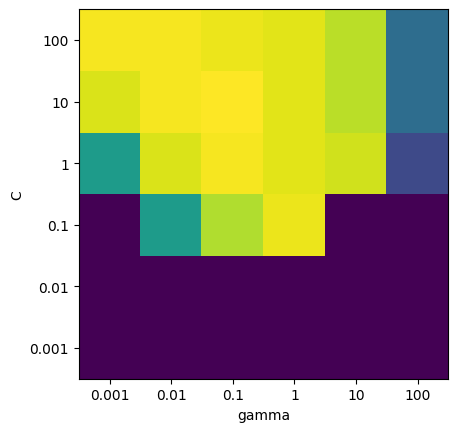

In [18]:
!pip install -q mglearn

import numpy as np
import matplotlib.pyplot as plt
import mglearn

scores = np.array(results.mean_test_score).reshape(6, 6)

mglearn.tools.heatmap(
    scores,
    xlabel='gamma',
    xticklabels=param_grid['gamma'],
    ylabel='C',
    yticklabels=param_grid['C'],
    cmap='viridis'
)

plt.show()

Heatmap membantu kita melihat apakah rentang parameter yang kita pilih sudah tepat. Jika nilai terbaik berada di tepi grid, kita mungkin perlu memperluas pencarian kita.

**Grid Search dengan Parameter Kondisional**

In [19]:
param_grid = [{'kernel': ['rbf'], 'C': [0.1, 1, 10], 'gamma': [0.1, 1]},
              {'kernel': ['linear'], 'C': [0.1, 1, 10]}]

grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(X_train, y_train)
print(f"Parameter terbaik: {grid_search.best_params_}")

Parameter terbaik: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


 Kita bisa menggunakan daftar dictionary untuk menangani parameter yang saling bergantung (misal: parameter gamma hanya relevan jika kernelnya adalah 'rbf').

**Nested Cross-Validation**

In [20]:
scores = cross_val_score(GridSearchCV(SVC(), param_grid, cv=5),
                         iris.data, iris.target, cv=5)
print(f"Skor Nested CV: {scores}")
print(f"Rata-rata: {scores.mean():.2f}")

Skor Nested CV: [0.96666667 1.         0.9        0.96666667 1.        ]
Rata-rata: 0.97


Nested CV melakukan grid search di dalam setiap loop cross-validation. Ini adalah metode paling akurat untuk mengevaluasi seberapa baik sebuah algoritma (beserta proses tuningnya) bekerja pada dataset tertentu.

**Confusion Matrix pada Data Tidak Seimbang**

In [21]:
from sklearn.metrics import confusion_matrix
from sklearn.datasets import load_digits

digits = load_digits()
y = digits.target == 9 # Membuat masalah klasifikasi biner "angka 9" vs "lainnya"
X_train, X_test, y_train, y_test = train_test_split(digits.data, y, random_state=0)

logreg = LogisticRegression(max_iter=1000).fit(X_train, y_train)
pred_logreg = logreg.predict(X_test)
print(f"Confusion Matrix:\n{confusion_matrix(y_test, pred_logreg)}")

Confusion Matrix:
[[399   4]
 [  6  41]]


Akurasi bisa menyesatkan jika dataset tidak seimbang. Confusion matrix menunjukkan detail jumlah True Positive, False Positive, True Negative, dan False Negative

** Laporan Klasifikasi Lengkap**

In [22]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred_logreg, target_names=["not nine", "nine"]))

              precision    recall  f1-score   support

    not nine       0.99      0.99      0.99       403
        nine       0.91      0.87      0.89        47

    accuracy                           0.98       450
   macro avg       0.95      0.93      0.94       450
weighted avg       0.98      0.98      0.98       450



Laporan ini merangkum metrik Precision (seberapa akurat prediksi positif), Recall (seberapa banyak data positif yang tertangkap), dan F1-score (rata-rata harmonik keduanya).

**Precision-Recall Curve**

Text(0, 0.5, 'Recall')

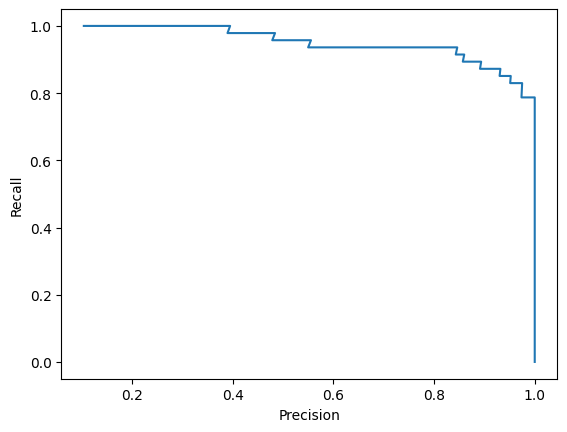

In [23]:
from sklearn.metrics import precision_recall_curve

# Menggunakan decision function untuk mendapatkan skor kepastian
precision, recall, thresholds = precision_recall_curve(y_test, logreg.decision_function(X_test))

plt.plot(precision, recall, label="precision recall curve")
plt.xlabel("Precision")
plt.ylabel("Recall")

Kurva ini membantu kita memilih titik operasi yang tepat. Misalnya, jika kita ingin meminimalkan False Negative, kita mungkin butuh Recall yang sangat tinggi.

**ROC Curve dan AUC**

Skor AUC: 0.99


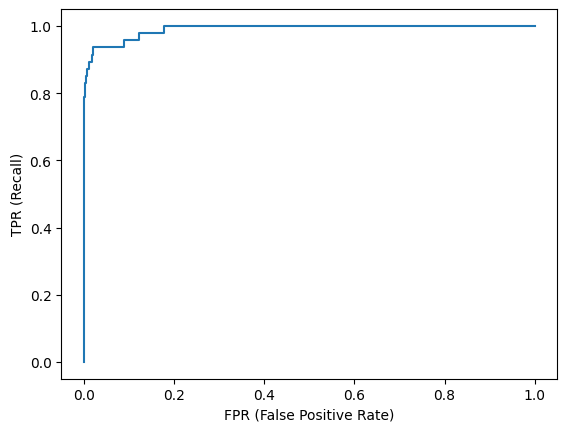

In [24]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, logreg.decision_function(X_test))
plt.plot(fpr, tpr, label="ROC Curve")
plt.xlabel("FPR (False Positive Rate)")
plt.ylabel("TPR (Recall)")

print(f"Skor AUC: {roc_auc_score(y_test, logreg.decision_function(X_test)):.2f}")

OC Curve membandingkan Recall terhadap tingkat kesalahan positif. Skor AUC (Area Under Curve) merangkum kurva ini menjadi satu angka; skor 1.0 adalah sempurna, sedangkan 0.5 setara dengan tebakan acak


**Menggunakan Metrik Kustom di GridSearchCV**

In [25]:
# Mencari parameter terbaik berdasarkan skor AUC, bukan akurasi standar
grid = GridSearchCV(SVC(), param_grid={'gamma': [0.01, 0.1, 1]}, scoring="roc_auc", cv=5)
grid.fit(X_train, y_train)
print(f"Parameter terbaik (berbasis AUC): {grid.best_params_}")
print(f"Skor AUC terbaik: {grid.best_score_:.2f}")

Parameter terbaik (berbasis AUC): {'gamma': 0.01}
Skor AUC terbaik: 1.00
